# IA 340 MINI PROJECT
### Electric Vehicle Population of Washington State

### Research Question: Which counties in Washington state have the most electric vehicles?

### Dataset Documentation
- **Source:** https://catalog.data.gov/dataset/electric-vehicle-population-data
- **Descriptino:** Make and model of electric vehicles througout Washington State
- **Time Period:** Created in 2020, updated in 2025
- **Reason for Choice:** I found it interesting to look at how many electric vehicles are in the state of Washington

In [53]:
import warnings
warnings.simplefilter('ignore')

import pandas as pd

df_unclean = pd.read_csv('s3://ia340-2025-fall-wei-demo-5465148971/Electric_Vehicle_Population_Data.csv')
df_unclean.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,WA1E2AFY8R,Thurston,Olympia,WA,98512,2024,AUDI,Q5 E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,23,0,22,263239938,POINT (-122.90787 46.9461),PUGET SOUND ENERGY INC,53067010910
1,WAUUPBFF4J,Yakima,Wapato,WA,98951,2018,AUDI,A3,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,16,0,15,318160860,POINT (-120.42083 46.44779),PACIFICORP,53077940008
2,1N4AZ0CP0F,King,Seattle,WA,98125,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84,0,46,184963586,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033000700
3,WA1VAAGE5K,King,Kent,WA,98031,2019,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,204,0,11,259426821,POINT (-122.17743 47.41185),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033029306
4,7SAXCAE57N,Snohomish,Bothell,WA,98021,2022,TESLA,MODEL X,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1,208182236,POINT (-122.18384 47.8031),PUGET SOUND ENERGY INC,53061051922


# Clean

In [64]:
import pandas as pd

print("Dataset Info:")
print(df_unclean.info())

print("\nStatistical Summary:")
print(df_unclean.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15959 entries, 0 to 15958
Data columns (total 17 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   VIN (1-10)                                         15959 non-null  object
 1   County                                             15959 non-null  object
 2   City                                               15959 non-null  object
 3   State                                              15959 non-null  object
 4   Postal Code                                        15959 non-null  int64 
 5   Model Year                                         15959 non-null  int64 
 6   Make                                               15959 non-null  object
 7   Model                                              15959 non-null  object
 8   Electric Vehicle Type                              15959 non-null  object
 9   Cle

In [55]:
print(df_unclean.isnull().sum())

VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64


As you can see, there are not any missing values in the dataset. This is probably because prior to uploading the Excel file, I went through and deleted the missing and duplicated values myself.

# Process/Aggregate

In [65]:
df["Make"] = df["Make"].str.strip().str.upper()

kia_df = df[df["Make"] == "KIA"]

kia_model_counts = (
    kia_df["Model"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Occurrences of each KIA model:\n")
print(kia_model_counts.to_string())

Occurrences of each KIA model:

Model
NIRO        368
EV6         221
EV9         143
SOUL         79
SPORTAGE     66
SORENTO      66
OPTIMA       32


This aggregate shows the different models of Kia that were recorded, and counts how often they were recorded. This analysis was made by filtering out every other make of car except Kia in the "Make" column, and finding which model of Kia occurred the most in the "Model" column. 

# Query

In [59]:
df[df['Make']=='KIA']

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
5,KNDJP3AEXG,Snohomish,Lynnwood,WA,98037,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93,31950,21,209171889,POINT (-122.27734 47.83785),PUGET SOUND ENERGY INC,53061051928
7,KNDCC3LG4L,Snohomish,Brier,WA,98036,2020,KIA,NIRO,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,239,0,1,281365724,POINT (-122.29245 47.82557),PUGET SOUND ENERGY INC,53061051914
38,KNDPYDDH1S,Snohomish,Lynnwood,WA,98087,2025,KIA,SPORTAGE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,34,0,21,278025401,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,53061041816
39,KNDCC3LGXK,King,Burien,WA,98146,2019,KIA,NIRO,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,239,0,34,3523768,POINT (-122.36178 47.49408),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033026700
41,KNDCR3LF5P,Yakima,Yakima,WA,98902,2023,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,33,0,14,258750306,POINT (-120.51904 46.59783),PACIFICORP,53077000700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15851,KNDC34LA7N,Snohomish,Bothell,WA,98012,2022,KIA,EV6,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,44,272405507,POINT (-122.21061 47.83448),PUGET SOUND ENERGY INC,53061052010
15879,5XYADFS58S,King,Bothell,WA,98011,2025,KIA,EV9,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1,281278273,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033021802
15908,5XYAA5S21T,King,Maple Valley,WA,98038,2026,KIA,EV9,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,5,283990290,POINT (-122.04526 47.39394),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032010
15912,KNDCE3LG3M,King,Maple Valley,WA,98038,2021,KIA,NIRO,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,5,276221375,POINT (-122.04526 47.39394),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032011


This table only shows the entries that have "KIA" listed in the "Make" column.

# Visualize

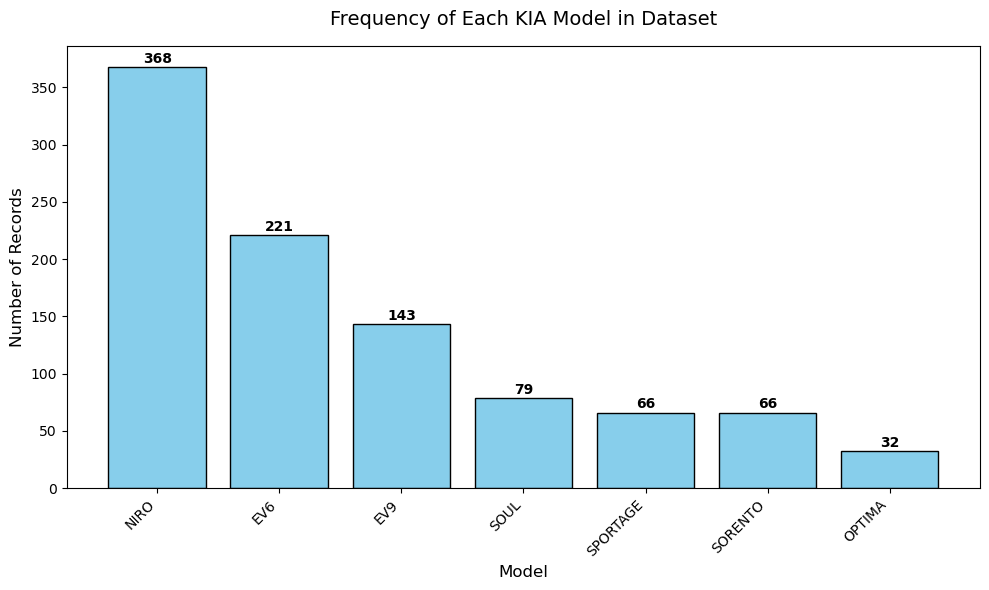

In [60]:
import matplotlib.pyplot as plt

kia_df = df[df["Make"].str.upper() == "KIA"]

kia_counts = kia_df["Model"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(kia_counts.index, kia_counts.values, color="skyblue", edgecolor="black")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,  # position
             f"{int(height)}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Frequency of Each KIA Model in Dataset", fontsize=14, pad=15)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

This graph shows how frequently each model of Kia was recorded. According to the graph, the most popular model of Kia in Washington state is the Kia Niro. With 368 unique recordings.

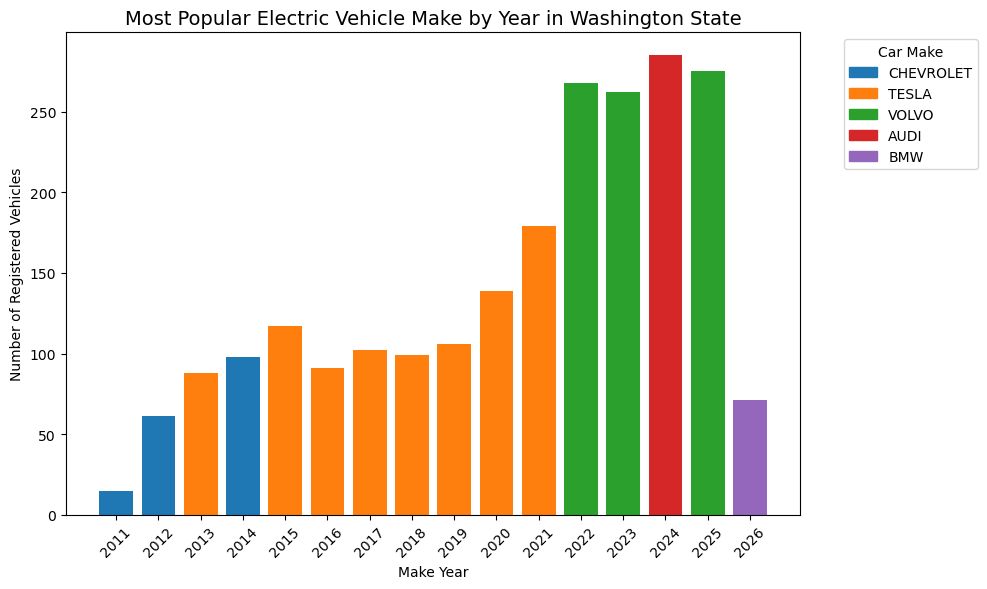

In [63]:
df = df.dropna(subset=['Model Year', 'Make'])
df = df[df['Model Year'] >= 2011]

make_counts = df.groupby(['Model Year', 'Make']).size().reset_index(name='Count')

top_makes = make_counts.loc[make_counts.groupby('Model Year')['Count'].idxmax()]

top_makes = top_makes.sort_values('Model Year')

plt.figure(figsize=(10,6))

unique_makes = top_makes['Make'].unique()
colors = plt.cm.tab10.colors
color_map = {make: colors[i % len(colors)] for i, make in enumerate(unique_makes)}

for i, row in top_makes.iterrows():
    plt.bar(str(row['Model Year']), row['Count'], color=color_map[row['Make']])

handles = [plt.Rectangle((0,0),1,1, color=color_map[m]) for m in unique_makes]
plt.legend(handles, unique_makes, title='Car Make', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Most Popular Electric Vehicle Make by Year in Washington State', fontsize=14)
plt.xlabel('Make Year')
plt.ylabel('Number of Registered Vehicles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This graph shows the most popular make of car during a specific year. This analysis was made by going through the "Model Year" column and finding which make of car occurred the most.